In [1]:
import numpy as np
import pandas as pd
from pandas import Timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error 

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import load_model

from scipy import signal
%matplotlib inline

NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
# Loading the raw final DataFrame
df = pd.read_csv(r'..\..\data_cleaned\merged\02_4_clean_data.csv')

In [3]:
# Converting date columns to datetime and filtering for 2019-2024 period

df['date'] = pd.to_datetime(df['date'])
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'])

start_date_df = '2019-01-01'
end_date_df = '2025-12-31'
df = df.query("date >= @start_date_df")
df = df.query("date <= @end_date_df")

print (df['load_forecast_da'].isna().sum())
print (df.columns)

0
Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'dayofweek',
       'price', 'period_start_utc', 'period_end_utc', 'load_forecast_da',
       'off_wind_da', 'on_wind_da', 'solar_da', 'gen_forecast_da',
       'res_sum_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1',
       'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday',
       'day_type', 'price_gas'],
      dtype='object')


In [4]:
# Ensure timestamp index
df.set_index('period_start_utc', inplace=True)

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2019-2025')

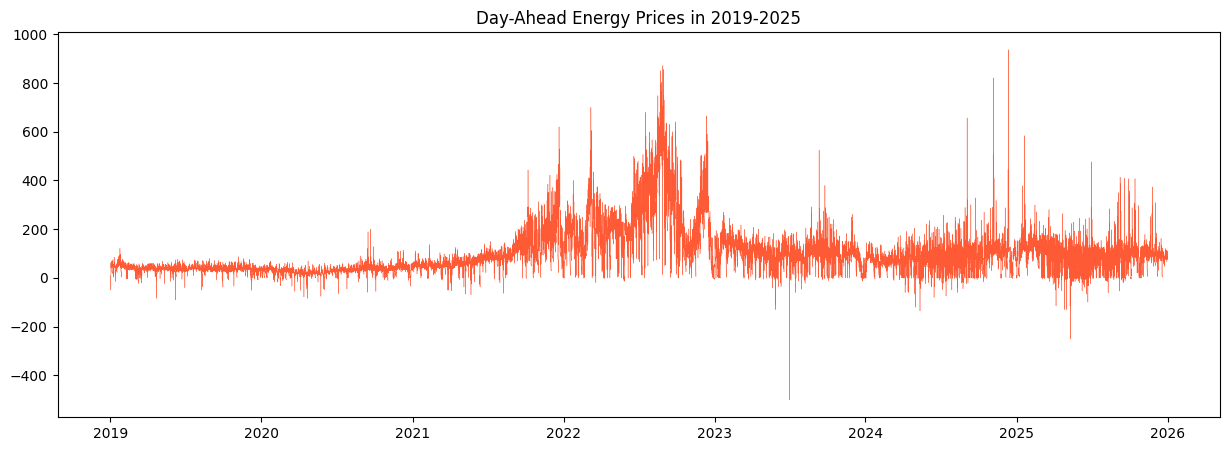

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['price'], label='Price', color=NF_ORANGE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2019-2025')

## LSTM
<p> Last layer has 1/24/168 output neurons - predicting next 1/24/168 hours at once. Using only price for predicting.
<p> Experimenting with various output layers: 1, 24, 168

In [6]:
# 2. Add residual_load = load - RES and dummies for a year

df["residual_load"] = (
    df["load_forecast_da"]
    - df["off_wind_da"]
    - df["on_wind_da"]
    - df["solar_da"]
)

df["year"] = df["date"].dt.year
df = pd.get_dummies(df, columns=["year"], drop_first=True, dtype=int)
df.columns

Index(['date', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas',
       'residual_load', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'year_2025'],
      dtype='object')

In [7]:
# Splitting into train and test sets before normalizing

df['date'] = pd.to_datetime(df['date']).dt.tz_localize('UTC')

split_date = pd.Timestamp('2025-01-01', tz='UTC')

train_df = df[df['date'] < split_date]
test_df = df[df['date'] >= split_date]

train_df.shape, test_df.shape

((52608, 30), (8759, 30))

In [8]:
# LSTM requires normalized inputs. Scaling after the split to avoid data leakage.

price_scaler = MinMaxScaler(feature_range=(-1, 1))

scaled_train = train_df.copy()
scaled_test = test_df.copy()

scaled_train['price'] = price_scaler.fit_transform(train_df[['price']])
scaled_test['price'] = price_scaler.transform(test_df[['price']])

# Turning DataFrame into Numpy array
scaled_train = scaled_train[['price']].values
scaled_test = scaled_test[['price']].values

print (len(scaled_train), len(scaled_test))
scaled_train[:5], scaled_test[:5]

52608 8759


(array([[-0.28973459],
        [-0.30943827],
        [-0.31755647],
        [-0.31407525],
        [-0.32123263]]),
 array([[-0.30152895],
        [-0.30375693],
        [-0.30377085],
        [-0.30377085],
        [-0.30384048]]))

In [9]:
# Create sequences (lags) - in this case our lag is 1 day, i.e. 24 hours

X_train, y_train = [], []
lookback = 24

for i in range(lookback, len(scaled_train)-24):
    X_train.append(scaled_train[i-lookback:i])
    y_train.append(scaled_train[i:i+24, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
print (X_train.shape, y_train.shape)

X_test, y_test = [], []

for i in range(lookback, len(scaled_test)-24):
    X_test.append(scaled_test[i-lookback:i])
    y_test.append(scaled_test[i:i+24, 0])
X_test, y_test = np.array(X_test), np.array(y_test)
print (X_test.shape, y_test.shape)

(52560, 24, 1) (52560, 24)
(8711, 24, 1) (8711, 24)


In [10]:
# Building the LSTM model

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(lookback, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(24)  # predicting 24 hours (1 day) at once
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 128)           66560     
                                                                 
 dropout (Dropout)           (None, 24, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 24)                1560      
                                                                 
Total params: 117528 (459.09 KB)
Trainable params: 117528 (459.09 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
# Train the model
training = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20

688/688 [==============================] - 272s 385ms/step - loss: 0.0033 - val_loss: 6.5766e-04
Epoch 2/20
688/688 [==============================] - 329s 478ms/step - loss: 8.7490e-04 - val_loss: 4.4240e-04
Epoch 3/20
688/688 [==============================] - 282s 409ms/step - loss: 7.1072e-04 - val_loss: 3.3880e-04
Epoch 4/20
688/688 [==============================] - 315s 458ms/step - loss: 6.1393e-04 - val_loss: 3.4508e-04
Epoch 5/20
688/688 [==============================] - 302s 438ms/step - loss: 6.1609e-04 - val_loss: 3.5827e-04
Epoch 6/20
688/688 [==============================] - 317s 461ms/step - loss: 6.2689e-04 - val_loss: 3.6175e-04
Epoch 7/20
688/688 [==============================] - 298s 433ms/step - loss: 5.8999e-04 - val_loss: 3.2623e-04
Epoch 8/20
688/688 [==============================] - 222s 322ms/step - loss: 5.8999e-04 - val_loss: 3.5105e-04
Epoch 9/20
688/688 [==============================] - 220s 320ms/step - loss: 5.7321e-04 - val_loss: 3.7484

### Loading pretrained on Google Colab model (ignore this if you trained model locally)

In [11]:
# Load the archive
with np.load(r'models\lstm_24to24_model_weights.npz') as data:
    # Reconstruct the list of weights in order
    weights_list = [data[f'arr_{i}'] for i in range(len(data.files))]

# Inject the numbers into your local model
model.set_weights(weights_list)

In [12]:
# Predict
y_pred = model.predict(X_test)

# Inverse transform to get actual price values
y_pred_inv = price_scaler.inverse_transform(y_pred)
y_test_inv = price_scaler.inverse_transform(y_test)

273/273 [==============================] - 5s 13ms/step


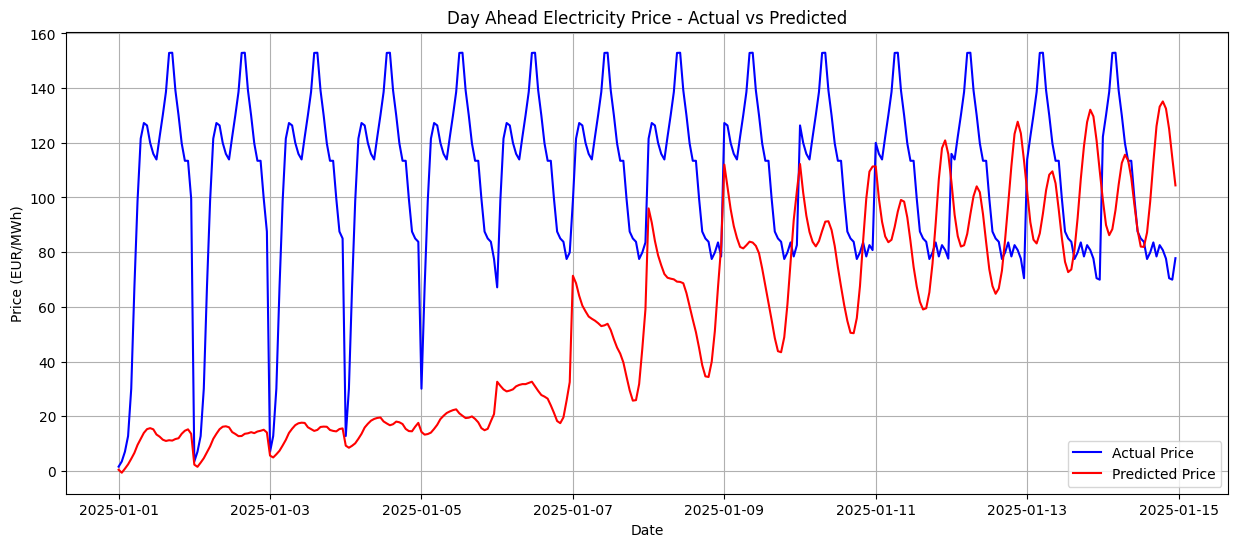

In [25]:
# Get corresponding dates from test_df (starting after lookback)
test_dates = test_df.index[0 : lookback + len(y_test_inv)]

# Flatten predictions and actuals - take first 14 days (336 hours)
n_hours = 336

plt.figure(figsize=(15, 6))
plt.plot(test_dates[:n_hours], y_test_inv.flatten()[:n_hours], label='Actual Price', color='blue')
plt.plot(test_dates[:n_hours], y_pred_inv.flatten()[:n_hours], label='Predicted Price', color='red')
plt.title('Day Ahead Electricity Price - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
y_pred_inv.shape, y_test_inv.shape

((8711, 24), (8711, 24))

In [16]:
for h in range(24):
    rmse_h = np.sqrt(mean_squared_error(y_test_inv[:, h], y_pred_inv[:, h]))
    print(f'Hour t+{h+1:03d} -> RMSE: {rmse_h:.2f}')

Hour t+001 -> RMSE: 19.00
Hour t+002 -> RMSE: 28.00
Hour t+003 -> RMSE: 32.23
Hour t+004 -> RMSE: 34.07
Hour t+005 -> RMSE: 35.07
Hour t+006 -> RMSE: 36.06
Hour t+007 -> RMSE: 36.94
Hour t+008 -> RMSE: 37.92
Hour t+009 -> RMSE: 39.31
Hour t+010 -> RMSE: 40.39
Hour t+011 -> RMSE: 40.56
Hour t+012 -> RMSE: 40.73
Hour t+013 -> RMSE: 41.06
Hour t+014 -> RMSE: 41.36
Hour t+015 -> RMSE: 41.53
Hour t+016 -> RMSE: 42.35
Hour t+017 -> RMSE: 43.26
Hour t+018 -> RMSE: 43.91
Hour t+019 -> RMSE: 44.30
Hour t+020 -> RMSE: 45.17
Hour t+021 -> RMSE: 46.28
Hour t+022 -> RMSE: 46.62
Hour t+023 -> RMSE: 45.98
Hour t+024 -> RMSE: 45.08


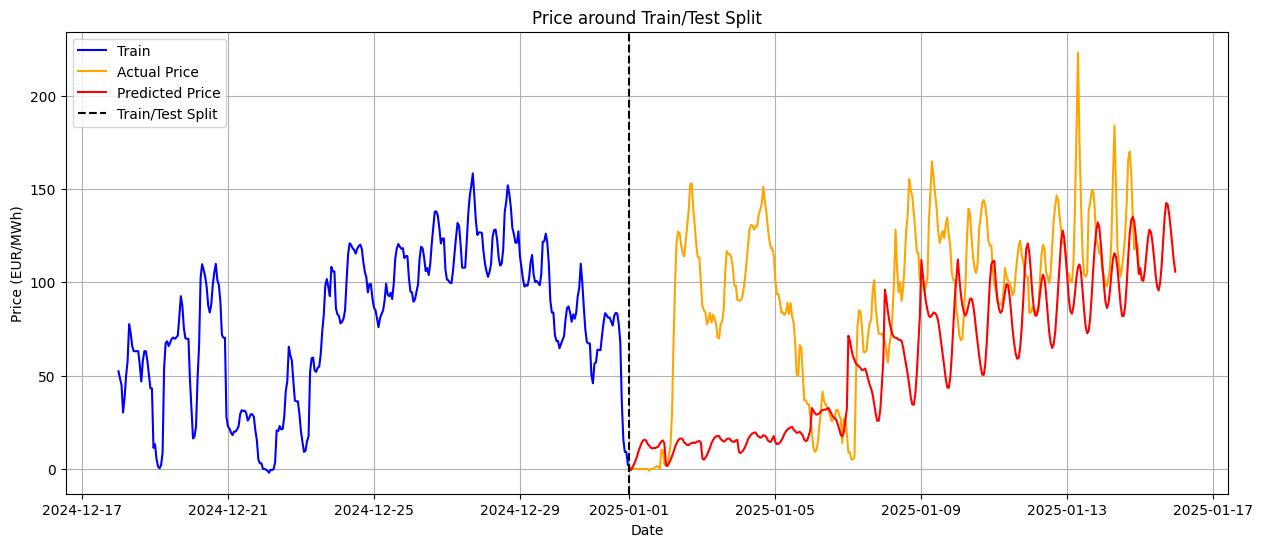

In [24]:
hours_xdays = 14 * 24

hours_xdays = pd.Timedelta(days=14)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv[:336:24]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]


plt.figure(figsize=(15, 6))
plt.plot(train_portion.index, train_portion['price'], label='Train', color='blue')
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color='orange')
plt.plot(pred_index, y_pred_inv.flatten()[:len(pred_index)], label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

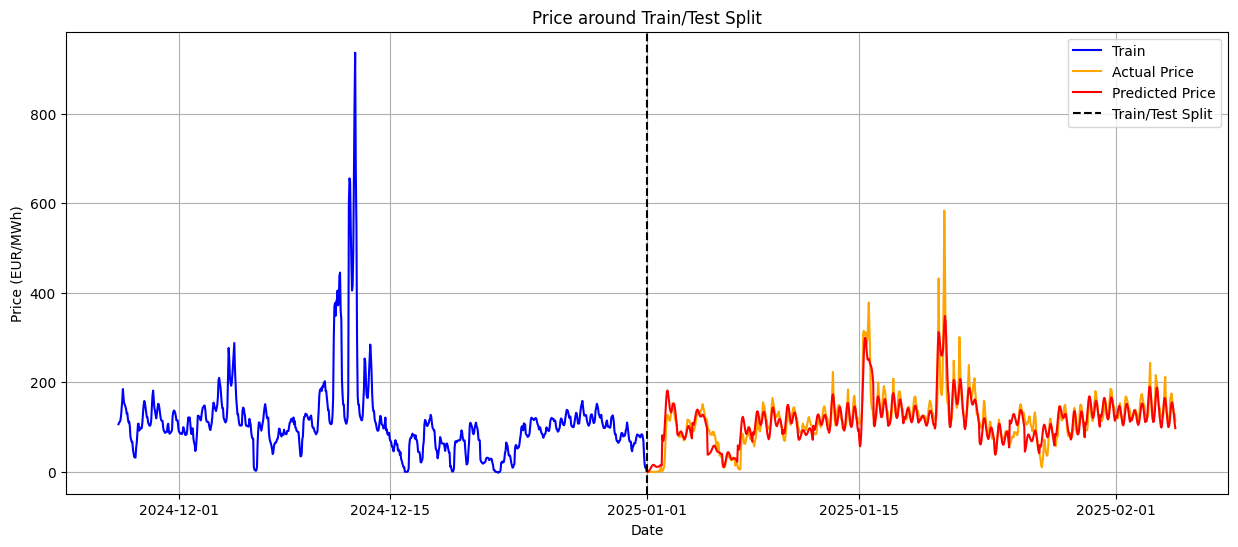

In [26]:
hours_xdays = 14 * 24

hours_xdays = pd.Timedelta(days=35)

train_portion = df.loc[(df.index >= split_date - hours_xdays) & (df.index < split_date)]
test_portion = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)]

# Create index for predictions (first 168 hours of test set)
#pred_index = df.loc[(df.index >= split_date) & (df.index < split_date + hours_xdays)].index

# Take non-overlapping 168-hour blocks
y_pred_daily = y_pred_inv[::24]  # shape: (n_days, 168)
pred_values = y_pred_daily.flatten()
pred_index = test_df.index[0 : lookback + len(pred_values)]

plt.figure(figsize=(15, 6))
plt.plot(train_portion.index, train_portion['price'], label='Train', color='blue')
plt.plot(test_portion.index, test_portion['price'], label='Actual Price', color='orange')
plt.plot(pred_index[0:840], pred_values[0:840], label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Price around Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

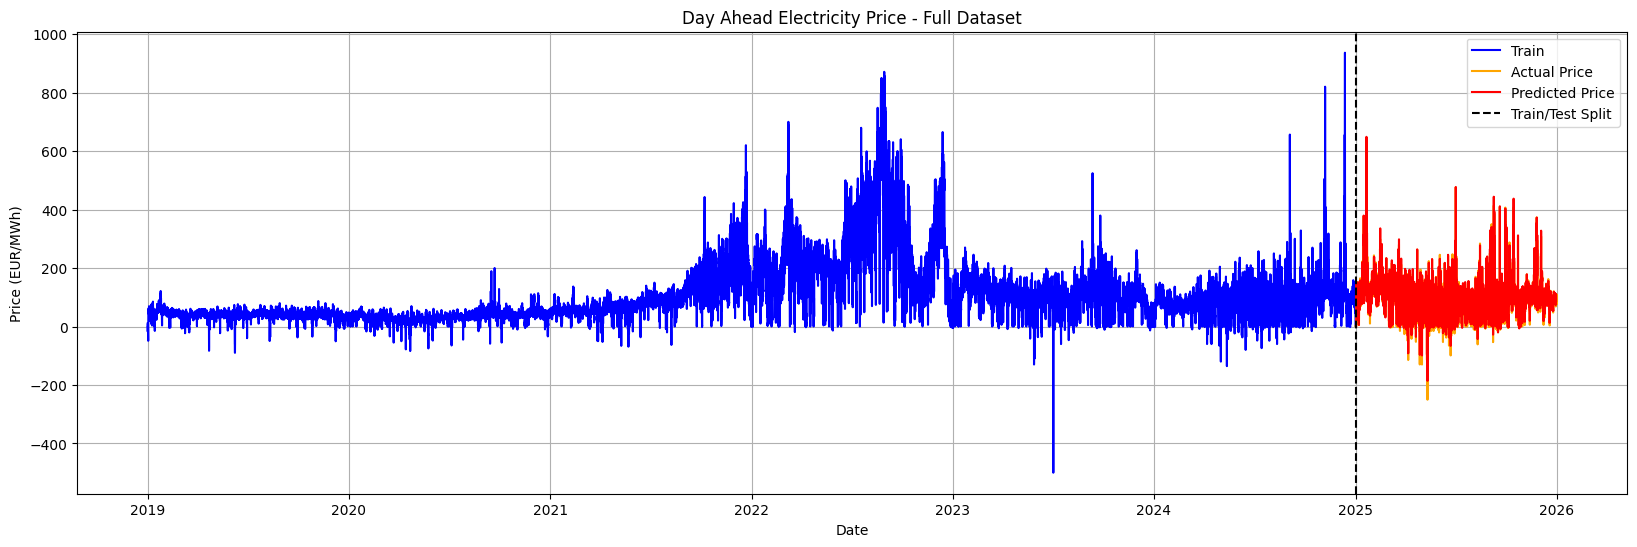

In [29]:
# Full prediction index covering entire test set
y_pred_t1 = y_pred_inv[:, 0]  # only t+1 from each sample
pred_index = test_df.index[lookback : lookback + len(y_pred_t1)]

plt.figure(figsize=(20, 6))
plt.plot(train_df.index, train_df['price'], label='Train', color='blue')
plt.plot(test_df.index, test_df['price'], label='Actual Price', color='orange')
plt.plot(pred_index, y_pred_t1, label='Predicted Price', color='red')
plt.axvline(x=split_date, color='black', linestyle='--', label='Train/Test Split')
plt.title('Day Ahead Electricity Price - Full Dataset')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Assessing RMSE and MAE

rmse = np.sqrt(mean_squared_error(y_test_inv.flatten(), y_pred_inv.flatten()))
mae = mean_absolute_error(y_test_inv.flatten(), y_pred_inv.flatten())

print(f'RMSE: {rmse:.2f} EUR/MWh')
print(f'MAE: {mae:.2f} EUR/MWh')

RMSE: 39.97 EUR/MWh
MAE: 27.20 EUR/MWh
